In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [70]:
RNG_SEED = 42
np.random.seed(RNG_SEED)

In [71]:
ALGO_NAMES = ['FCFS', 'SJF', 'Priority', 'RR']
FEATURES = ['BT', 'Resources', 'ArrivalTime', 'Priority', 'TimeQuantum']

df = pd.read_csv('DataSet2.csv')

In [72]:
bt_fill = df['BT'].mean()
res_fill = df['Resources'].median()
df['BT'] = df['BT'].fillna(bt_fill)
df['Resources'] = df['Resources'].fillna(res_fill)

print(f"Missing-value fill values -> BT mean: {bt_fill:.2f}, Resources median: {res_fill:.2f}")

def calculate_tat(row):
    """Simulate turnaround time under each algorithm and label the winner."""
    bt = row['BT']
    priority = row['Priority']
    quantum = row['TimeQuantum']

    noise = np.random.normal(0, 32)

    tat_fcfs = bt + noise
    tat_sjf = (bt * 0.8 + noise) if bt < 150 else (bt * 1.2 + noise)
    tat_priority = (bt * 0.75 + noise) if priority < 4 else (bt * 1.3 + noise)
    tat_rr = bt * (0.85 if quantum > 100 else 1.05) + noise

    results = {0: tat_fcfs, 1: tat_sjf, 2: tat_priority, 3: tat_rr}
    true_winner = min(results, key=results.get)

    # Deliberate label noise: ~8% of rows get a random algorithm assigned
    # instead of the true winner. With 4 classes, that caps the expected
    # achievable accuracy at ~1 - 0.08 + 0.08/4 = ~94%, regardless of model
    # quality -- expected, not a bug.
    if np.random.rand() < 0.08:
        return np.random.randint(0, 4)

    return true_winner


df['target'] = df.apply(calculate_tat, axis=1)
print("\nTarget distribution:\n", df['target'].value_counts())


Missing-value fill values -> BT mean: 260.37, Resources median: 5.00

Target distribution:
 target
2    1281
3     663
0     559
1     497
Name: count, dtype: int64


In [73]:
X = df[FEATURES].copy()
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RNG_SEED, stratify=y
)

In [74]:
models = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel='rbf', C=10, class_weight='balanced', random_state=RNG_SEED)),
    ]),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RNG_SEED)),
    ]),
    "SGD Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SGDClassifier(loss='log_loss', eta0=0.01, learning_rate='constant',
                               class_weight='balanced', random_state=RNG_SEED)),
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),  # harmless no-op for trees, kept for a uniform pipeline
        ("clf", RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RNG_SEED)),
    ]),
}

In [75]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)

print("\n--- 5-fold CV accuracy on training data (used for model selection) ---")
cv_scores = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f"{name:22s}: {scores.mean()*100:5.2f}%  (+/- {scores.std()*100:4.2f}%)")

best_name = max(cv_scores, key=cv_scores.get)
print(f"\nSelected by CV: {best_name}")


--- 5-fold CV accuracy on training data (used for model selection) ---
SVM                   : 90.46%  (+/- 1.56%)
Logistic Regression   : 84.58%  (+/- 0.71%)
SGD Classifier        : 87.00%  (+/- 0.96%)
Random Forest         : 93.42%  (+/- 1.12%)

Selected by CV: Random Forest



SVM test accuracy: 94.00%

Logistic Regression test accuracy: 86.50%

SGD Classifier test accuracy: 88.33%

Random Forest test accuracy: 95.50%
              precision    recall  f1-score   support

        FCFS       0.95      0.96      0.95       112
         SJF       0.96      0.92      0.94        99
    Priority       0.95      0.98      0.97       256
          RR       0.96      0.93      0.95       133

    accuracy                           0.95       600
   macro avg       0.96      0.95      0.95       600
weighted avg       0.96      0.95      0.95       600



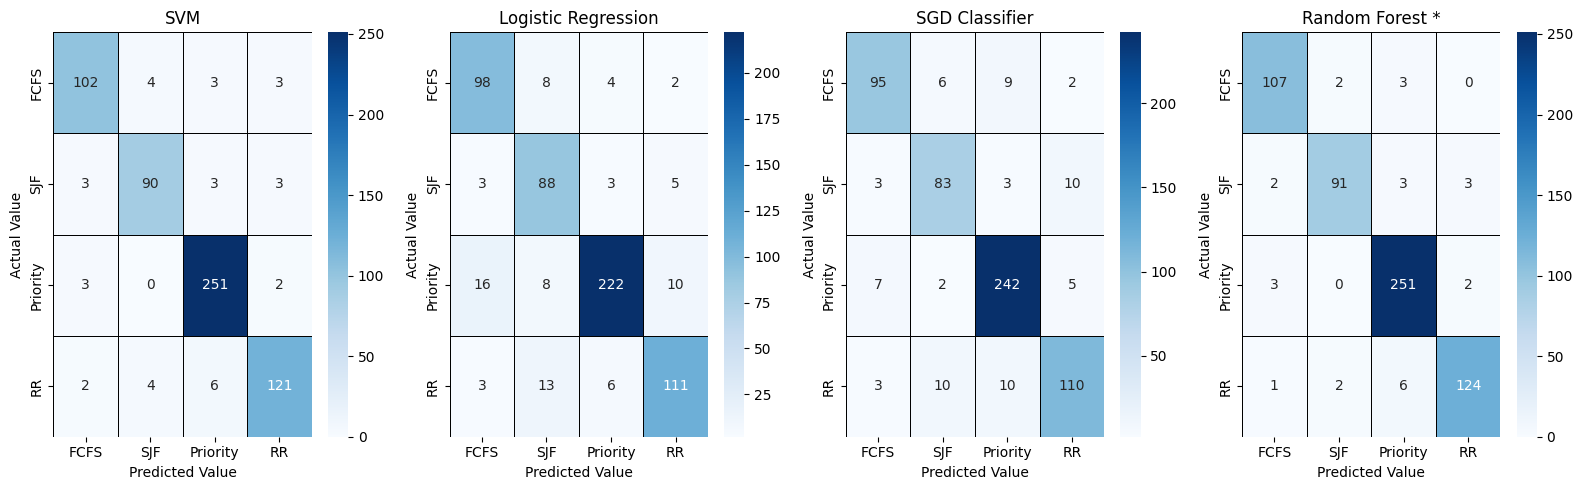


Final model: Random Forest, held-out test accuracy: 95.50%
(Ceiling is ~94% because ~8% of labels are intentionally randomized across 4 classes.)


In [76]:
fig, axes = plt.subplots(1, len(models), figsize=(16, 5))
test_accuracies = {}

for i, (name, pipe) in enumerate(models.items()):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_accuracies[name] = acc
    print(f"\n{name} test accuracy: {acc*100:.2f}%")
    if name == best_name:
        print(classification_report(y_test, y_pred, target_names=ALGO_NAMES, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ALGO_NAMES, yticklabels=ALGO_NAMES,
                linewidths=0.5, linecolor='black', cbar=True, ax=axes[i])
    axes[i].set_title(f"{name}" + (" *" if name == best_name else ""), fontsize=12)
    axes[i].set_xlabel("Predicted Value", fontsize=10)
    axes[i].set_ylabel("Actual Value", fontsize=10)

plt.tight_layout()
plt.show()

best_model = models[best_name]
best_acc = test_accuracies[best_name]
print(f"\nFinal model: {best_name}, held-out test accuracy: {best_acc*100:.2f}%")
print("(Ceiling is ~94% because ~8% of labels are intentionally randomized across 4 classes.)")


In [77]:
plot_df = df.head(10).copy().sort_values(by='ArrivalTime').reset_index(drop=True)
X_plot = plot_df[FEATURES]
plot_preds = best_model.predict(X_plot)

n = len(plot_df)
job_ids = plot_df.get('Jobid', plot_df.index).tolist()
arrival = plot_df['ArrivalTime'].tolist()
priority = plot_df['Priority'].tolist()
quantum = plot_df['TimeQuantum'].tolist()
remaining_bt = plot_df['BT'].tolist()
algo = plot_preds.tolist()

enqueue_time = [None] * n     # time each job most recently entered the ready queue
arrived = [False] * n
ready_queue = []
current = None
time = 0.0
gantt = []

In [78]:
def select_next_job(queue):
    """Pick the next job to run from a queue that may mix algorithms."""
    if not queue:
        return None
    if len(queue) == 1:
        return queue[0]

    def raw_key(idx):
        a = algo[idx]
        if a == 0:      # FCFS -> earliest arrival first
            return arrival[idx]
        elif a == 1:    # SJF -> shortest remaining burst first
            return remaining_bt[idx]
        elif a == 2:    # Priority -> lowest priority number first
            return priority[idx]
        else:           # RR -> longest-waiting-in-queue first (FIFO)
            return enqueue_time[idx]

    # Normalize within each algorithm group so a "3" (priority) and a
    # "170" (arrival time) aren't compared on raw magnitude.
    groups = {}
    for idx in queue:
        groups.setdefault(algo[idx], []).append(idx)

    normalized = {}
    for members in groups.values():
        vals = [raw_key(idx) for idx in members]
        lo, hi = min(vals), max(vals)
        span = (hi - lo) or 1.0
        for idx, v in zip(members, vals):
            normalized[idx] = (v - lo) / span

    return min(queue, key=lambda idx: (normalized[idx], arrival[idx], idx))

In [79]:
while any(not a for a in arrived) or ready_queue or current is not None:
    # Admit newly arrived jobs
    for idx in range(n):
        if not arrived[idx] and arrival[idx] <= time:
            arrived[idx] = True
            enqueue_time[idx] = time
            ready_queue.append(idx)

    if current is None:
        if not ready_queue:
            future_arrivals = [arrival[i] for i in range(n) if not arrived[i]]
            time = min(future_arrivals)
            continue
        current = select_next_job(ready_queue)
        ready_queue.remove(current)

    idx = current
    a = algo[idx]

    if a in (0, 1):                       # FCFS / SJF: run to completion
        run_time = remaining_bt[idx]
    elif a == 2:                          # Priority: preemptable, so cap the
        run_time = remaining_bt[idx]      # slice at the next arrival to re-check
        future_arrivals = [arrival[i] for i in range(n) if not arrived[i]]
        if future_arrivals:
            run_time = min(run_time, max(0.0, min(future_arrivals) - time))
        run_time = max(run_time, 1e-9)
    else:                                  # RR: capped by quantum
        run_time = min(remaining_bt[idx], quantum[idx])

    start_time = time
    time += run_time
    remaining_bt[idx] -= run_time
    gantt.append((job_ids[idx], start_time, run_time, a))

    # Admit anyone who arrived during this slice
    for i in range(n):
        if not arrived[i] and arrival[i] <= time:
            arrived[i] = True
            enqueue_time[i] = time
            ready_queue.append(i)

    finished = remaining_bt[idx] <= 1e-9

    if finished:
        current = None
    elif a == 2:
        # Preempt only if a strictly-better-priority job is now waiting
        better = [i for i in ready_queue if priority[i] < priority[idx]]
        if better:
            enqueue_time[idx] = time
            ready_queue.append(idx)
            current = None
        # else: keep running the same job, loop will recompute its next slice
    elif a == 3:
        enqueue_time[idx] = time
        ready_queue.append(idx)
        current = None
    else:
        # FCFS/SJF should never reach here with remaining > 0 since they
        # run to completion in one slice, but guard anyway.
        current = None


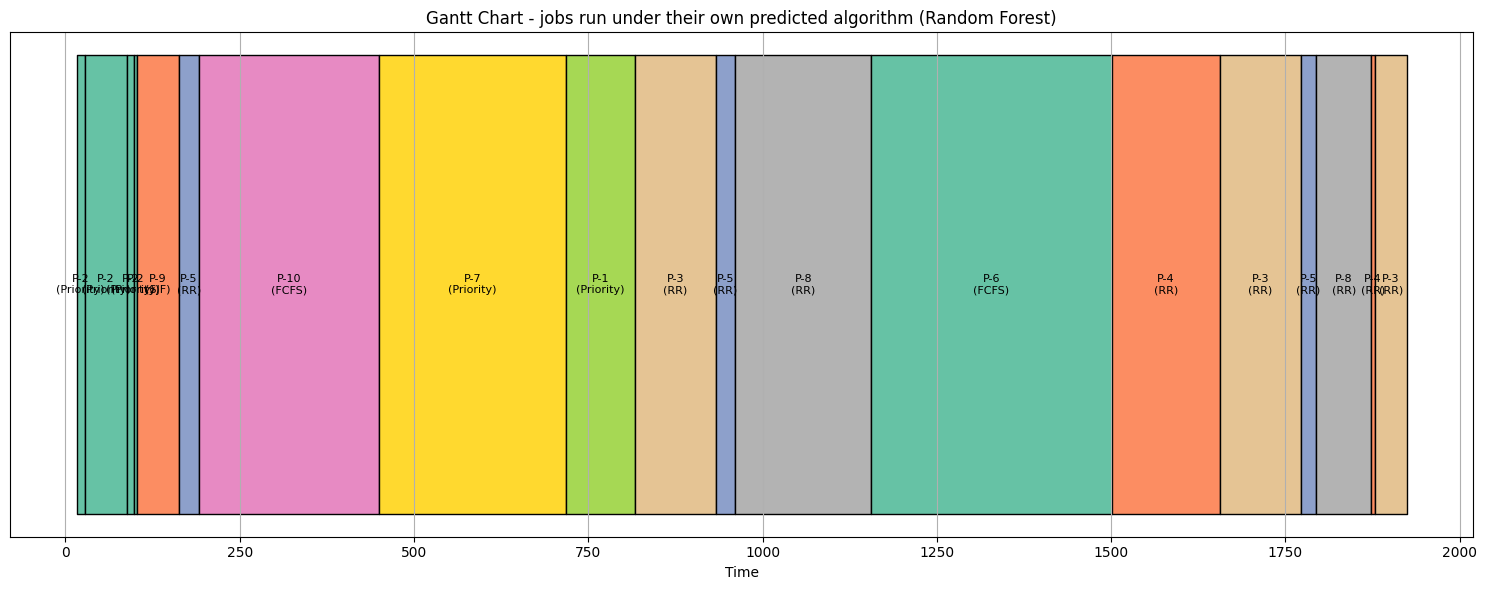

In [80]:
plt.figure(figsize=(15, 6))
palette = sns.color_palette("Set2", len(job_ids))
job_color_map = {job: palette[i] for i, job in enumerate(job_ids)}

for job, start, duration, pred in gantt:
    plt.broken_barh([(start, duration)], (10, 8),
                     facecolors=job_color_map[job], edgecolor='black')
    plt.text(start + duration / 2, 14, f"P-{job}\n({ALGO_NAMES[pred]})",
              ha='center', va='center', fontsize=8)

plt.title(f"Gantt Chart - jobs run under their own predicted algorithm ({best_name})")
plt.xlabel("Time")
plt.yticks([])
plt.grid(axis='x')
plt.tight_layout()
plt.show()